In [2]:
import pandas as pd

In [5]:
data={
    "study_hours":[1,2,3,4,5,6,7,8],
    "marks":[35,42,50,58,65,72,80,88]
}
df=pd.DataFrame(data)
df

,study_hours,marks
0,1,35
1,2,42
2,3,50
3,4,58
4,5,65
5,6,72
6,7,80
7,8,88


In [6]:
df.to_csv("student_marks.csv",index=False)

In [7]:
import os

print (os.getcwd())
print(os.path.exists("student_marks.csv"))

C:\Users\ACER
True


In [8]:
import pandas as pd
df=pd.read_csv("student_marks.csv")
df.head()

,study_hours,marks
0,1,35
1,2,42
2,3,50
3,4,58
4,5,65


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   study_hours  8 non-null      int64
 1   marks        8 non-null      int64
dtypes: int64(2)
memory usage: 260.0 bytes


In [11]:
print("Shape:", df.shape)

Shape: (8, 2)


In [12]:
x=df[["study_hours"]]
y=df["marks"]

In [13]:
print("x:")
print(x)

print("\ny:")
print(y)

x:
   study_hours
0            1
1            2
2            3
3            4
4            5
5            6
6            7
7            8

y:
0    35
1    42
2    50
3    58
4    65
5    72
6    80
7    88
Name: marks, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
print("Training input:", x_train.shape)
print("Testing input:", x_test.shape)

print("Training output:", y_train.shape)
print("Testing output:", y_test.shape)

Training input: (6, 1)
Testing input: (2, 1)
Training output: (6,)
Testing output: (2,)


In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
model = LinearRegression()

In [18]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
print("coefficient:",model.coef_[0])
print("Intercept:", model.intercept_)

coefficient: 7.539999999999998
Intercept: 27.480000000000004


In [20]:
print(
    f"Equation: Marks = {model.coef_[0]:.2f} × Study Hours + {model.intercept_:.2f}"
)

Equation: Marks = 7.54 × Study Hours + 27.48


In [22]:
y_pred = model.predict(x_test)

print("Predicted Marks:")
print(y_pred)

Predicted Marks:
[42.56 72.72]


In [23]:
comparison = pd.DataFrame({
    "Study Hours": x_test["study_hours"].values,
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred
})

comparison

,Study Hours,Actual Marks,Predicted Marks
0,2,42,42.56
1,6,72,72.72


In [25]:
new_student = pd.DataFrame({
    "study_hours": [9]
})

prediction = model.predict(new_student)

print("Predicted Marks:", prediction[0])

Predicted Marks: 95.33999999999999


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 0.6400000000000006
MSE: 0.4160000000000005
R² Score: 0.9981511111111111


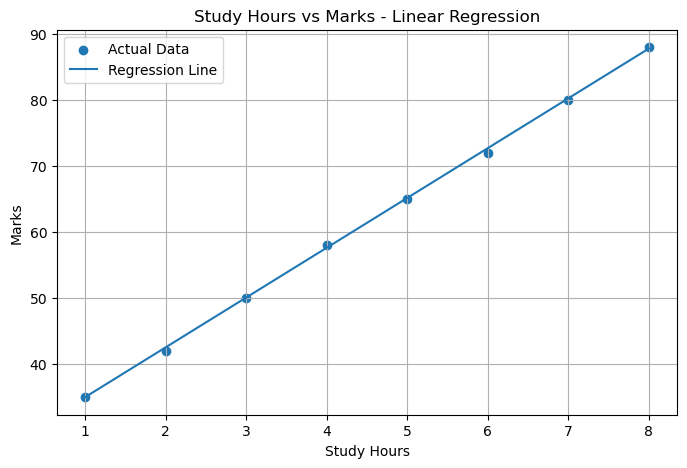

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Actual data points
plt.scatter(
    x["study_hours"],
    y,
    label="Actual Data"
)

# Regression line
plt.plot(
    x["study_hours"],
    model.predict(x),
    label="Regression Line"
)

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks - Linear Regression")
plt.legend()
plt.grid(True)

plt.show()